### Data Loaders ###

Code for processing data samples can get messy and hard to maintain; we ideally want our dataset code to be decoupled from our model training code for better readability and modularity. PyTorch provides two data primitives: torch.utils.data.DataLoader and torch.utils.data.Dataset that allow you to use pre-loaded datasets as well as your own data. Dataset stores the samples and their corresponding labels, and DataLoader wraps an iterable around the Dataset to enable easy access to the samples.

https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [1]:
import sys
import os
import copy
import glob
import pandas as pd
import numpy as np
import albumentations as alb
from matplotlib import pyplot as plt
from dotenv import load_dotenv

import torch
from torch.utils.data import Dataset, DataLoader

# Appearance of the Notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Import this module with autoreload
%load_ext autoreload
%autoreload 2

import computervision as cv
from computervision.fileutils import FileOP
from computervision.imageproc import ImageData, is_image
from computervision.transformations import AugmentationTransform

# Print version info
print(f'Package version: {cv.__version__}')
print(f'Authors:         {cv.__authors__}')
print(f'Python version:  {sys.version}')

Package version: 0.0.1
Authors:         The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.13 (main, Apr 16 2026, 08:53:58) [GCC 13.3.0]


In [2]:
# Load environmental variables
load_dotenv()
data_root = os.environ.get('DATA_DIR')
if data_root is None:
    print('Edit the "env"file and copy it to the root of the repository.') 
    raise FileNotFoundError('No .env file found. The data directory was not set.')

# Directory to store the data
dataset_name = 'classification'
data_dir = os.path.join(data_root, dataset_name)
example_dir = os.path.join(data_dir, 'examples')

# URL with the data set for manual download
url = os.environ.get('CL_URL')
image_dir_name = os.path.basename(url).split('.')[0]
image_dir = os.path.join(data_dir, image_dir_name, 'cropped')

# Verify the image data on disk
file_list = glob.glob(os.path.join(image_dir, '*.jpg'))
print(len(file_list))

7697


In [3]:
# Load the annotations
annotations_file_name = 'annotations_cropped_dset.parquet'
annotations_file = os.path.join(image_dir, annotations_file_name)
df = pd.read_parquet(annotations_file)

file_col = 'file_name'
bbox_col= 'bbox'
label_col = 'label'

# Check the images
file_list = [os.path.join(image_dir, file_name) for file_name in df[file_col].unique()]
checked = [is_image(file) for file in file_list]
assert len(file_list) == sum(checked), f'WARNING: Could not open all {len(file_list)} images at: {image_dir}'
print(f'Image directory:        {image_dir}')
print(f'Total number of images: {len(file_list)}')
print(f'Annotations:            {df.shape[0]}')

Image directory:        /home/andreas/data/cv_data/classification/dataset_dental_roboflow/cropped
Total number of images: 7550
Annotations:            7550


### Create a category id for the model ####
The model cannot deal with labels like "apple" or "tree". Therefore, we need to convert the original labels into category ids which can be used as inputs to the model.

In [4]:
labels = list(df[label_col].unique())
print(labels)

label2id = dict(zip(labels, range(len(labels))))
id2label = {category_id: label for label, category_id in label2id.items()}
display(id2label)

# Now we can add a category id to the data frame
df = df.assign(category=df[label_col].apply(lambda label: label2id.get(label)))
display(df.head())

['tooth', 'amalgam', 'caries', 'composite', 'Calculus', 'root filling']


{0: 'tooth',
 1: 'amalgam',
 2: 'caries',
 3: 'composite',
 4: 'Calculus',
 5: 'root filling'}

,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox,dset,category
0,a0ab0bec5c.jpg,tooth_02_a0ab0bec5c.jpg,152,236,35872,tooth,None,[2],None,train,0
1,5c6869fdf0.jpg,amalgam_03_5c6869fdf0.jpg,427,265,113155,amalgam,"[182, 29, 119, 112]","[19, 20]","[[143, 20, 284, 245], [20, 33, 382, 232]]",train,1
2,96a9546c1e.jpg,caries_08_96a9546c1e.jpg,525,253,132825,caries,"[97, 97, 46, 32]","[19, 20]","[[129, 21, 396, 232], [20, 20, 256, 233]]",train,2
3,1e36413c9e.jpg,composite_05_1e36413c9e.jpg,535,241,128935,composite,"[67, 32, 169, 87]","[29, 30]","[[213, 44, 322, 197], [20, 20, 341, 221]]",train,3
4,872cd0d6f2.jpg,tooth_15_872cd0d6f2.jpg,213,181,38553,tooth,None,[15],None,train,0


### PyTorch dataset from a Pandas dataframe ###

In [5]:
class DatasetFromDF(Dataset):

    def __init__(self,
                 data,
                 image_dir,
                 file_name_col,
                 label_id_col,
                 max_image_size,
                 transform=None,
                 validate=False):
        
        self.df = data
        self.image_dir = image_dir
        self.file_name_col = file_name_col
        self.label_id_col = label_id_col
        self.max_image_size = max_image_size
        self.transform = transform
        self.validate = validate
        
        if self.validate:
            file_list = [os.path.join(image_dir, file) for file in data[file_name_col].unique()]
            checked = np.sum([is_image(file) for file in file_list])
            assert len(file_list) == checked, f'Error: Could not open all images in data'

    def __len__(self):
        return self.df.shape[0]

    def load_and_process_image(self, file, max_image_size):
        file = os.path.join(self.image_dir, file)
        image = ImageData().load_image(file)
        transforms = AugmentationTransform(max_size=max_image_size).\
            get_transforms(name='resize_and_pad')
        T = alb.Compose(transforms)
        return T(image=image)['image']

    def __getitem__(self, idx):
        idx = idx % self.__len__()
        df_idx = self.df.iloc[idx]
        file, label = df_idx[self.file_name_col], df_idx[self.label_id_col]
        assert isinstance(label, np.int64), f'Label must be type np.int64.'
        # Load image, then rescale and pad it to the maximum size
        img = self.load_and_process_image(file=file, max_image_size=self.max_image_size)
        if self.transform:
            img = self.transform(image=img)['image']
        img_tensor = torch.from_numpy(img).permute(2, 0, 1)
        # For grayscale images, we need to add a color dimension.
        # img_tensor = torch.unsqueeze(img_tensor, dim=0)
        # img_tensor = img_tensor.permute(2, 0, 1)
        label_tensor = torch.from_numpy(np.array(label))
        output = tuple([img_tensor, label_tensor])
        return output

In [6]:
# We want to scale and pad all images first to the maximum dimentsion
max_image_size = 640

# Then, the images will be scaled down to 
# the correct input size for the model
im_size = 512

# We then need a minimum transform for all images
# Scale the images to the correct input size of the model
# Apply any color normalization (for example ImageNet for dogs and cats)
transform = alb.Compose([alb.Resize(width=im_size, height=im_size),
                         alb.Normalize(mean=0, std=1)])

# Instantiate the DatasetFromDF class
dataset = DatasetFromDF(data=df,
                        image_dir=image_dir,
                        file_name_col=file_col,
                        label_id_col='category',
                        max_image_size=max_image_size,
                        transform=transform,
                        validate=True)

print(len(dataset))

7550


### Retrieve images from the data set using a data loader ###

In [7]:
def image_stats(ig, decimals=3):

    """ Returns pandas series with image stats """
    
    output_dict = {'im_width': ig.shape[1],
                   'im_height': ig.shape[0],
                   'im_min': np.round(np.min(ig), decimals=decimals),
                   'im_max': np.round(np.max(ig), decimals=decimals),
                   'im_mean': np.round(np.mean(ig), decimals=decimals),
                   'im_std': np.round(np.std(ig), decimals=decimals)}
                   
    return pd.DataFrame(output_dict, index=[0]).iloc[0]

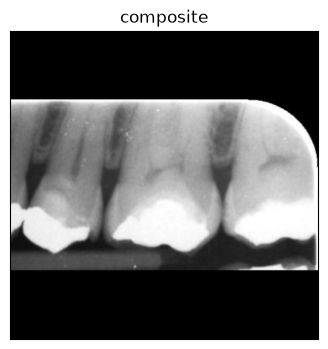

im_width     512.000
im_height    512.000
im_min         0.000
im_max         1.000
im_mean        0.326
im_std         0.356
Name: 0, dtype: float64

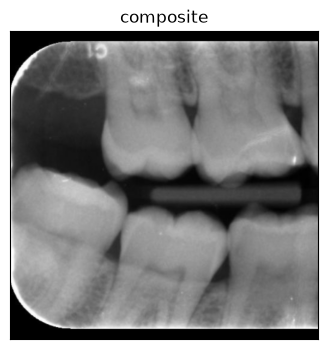

im_width     512.000
im_height    512.000
im_min         0.000
im_max         1.000
im_mean        0.426
im_std         0.224
Name: 0, dtype: float64

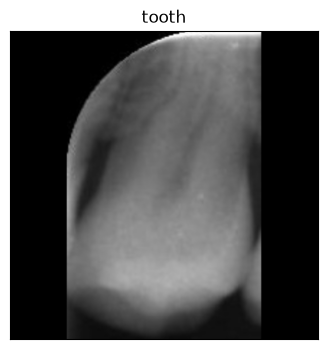

im_width     512.000
im_height    512.000
im_min         0.000
im_max         1.000
im_mean        0.239
im_std         0.234
Name: 0, dtype: float64

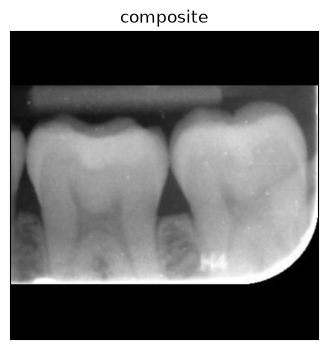

im_width     512.000
im_height    512.000
im_min         0.000
im_max         1.000
im_mean        0.347
im_std         0.312
Name: 0, dtype: float64

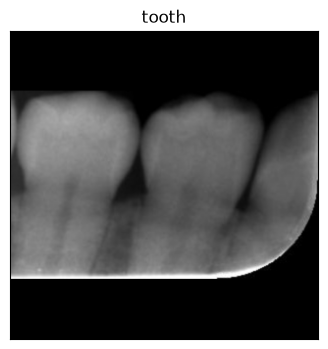

im_width     512.000
im_height    512.000
im_min         0.000
im_max         1.000
im_mean        0.221
im_std         0.225
Name: 0, dtype: float64

In [8]:
# Retrieve one (image, label) sample from the data set
for image_index in np.arange(10, 15, 1):
    # image_index = 24
    image_sample, label_sample = dataset[image_index]
    # We need to move the color channel back to the end of the array
    image = np.transpose(image_sample.numpy(), (1, 2, 0))
    label = id2label.get(int(label_sample.numpy()))
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(image)
    ax.set(xticks=[], yticks=[], title=str(label))
    plt.show()
    print()
    display(image_stats(image))

In [9]:
dataloader = DataLoader(dataset=dataset, batch_size=16)

# The dataloader can be converted into an iterator which returns images and labels
image_batch, label_batch = next(iter(dataloader))

print(f'Size of the image batch: {image_batch.numpy().shape}')
print(f'Labels:                  {label_batch.numpy()}')

Size of the image batch: (16, 3, 512, 512)
Labels:                  [0 1 2 3 0 0 0 0 0 0 3 3 0 3 0 2]


torch.Size([4, 3, 512, 512])
tensor([3, 0, 0, 5])


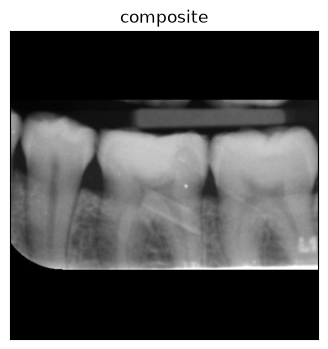

In [10]:
dl = DataLoader(dataset=dataset,
                batch_size=4,
                shuffle=True,
                pin_memory=True)

image_batch, label_batch = next(iter(dl))

print(image_batch.shape)
print(label_batch)

# Plot one image from the batch with label
image_idx = 0
image = np.transpose(image_batch.numpy()[image_idx], axes=(1, 2, 0))
label = id2label.get(label_batch.numpy()[image_idx])
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(image, cmap='gray')
ax.set_title(label)
ax.set(xticks=[], yticks=[])
plt.show()